# Построение моделей регрессии

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# из семинара
import statsmodels.api as sm # стандартные регрессионные модели
import statsmodels.formula.api as smf # аналогичные модели с синтаксисом в стиле R
import statsmodels.graphics.gofplots as gf # визуализация моделей
import statsmodels.discrete.discrete_model # дискретные модели
from statsmodels.stats.outliers_influence import summary_table # работа с выбросами
from scipy.stats import shapiro # тест Шапиро – Уилка
import math

In [2]:
df = pd.read_csv('processed_data_tennis_scaled_v2.csv')

## Отбираем те признаки, которые остались после отбора фичей (ноутбук 'baseline_linreg')
df = df[['has_higher_sport_education', 'sport_master',
       'sport_master_kandidate', 'is_champion', 'reviews_count', 'photos_count', 'is_male',
       'work_experience_sq', 'work_experience', 'reputation_density', 'has_price', 'price_in_thousands']]

# берем только данные, для которых указана цена
data_priced = df[df['has_price'] == 1].copy()
data_priced = data_priced[['has_higher_sport_education', 'sport_master',
       'sport_master_kandidate', 'is_champion', 'reviews_count', 'photos_count', 'is_male',
       'work_experience_sq', 'work_experience', 'reputation_density', 'price_in_thousands']]


data_priced

,has_higher_sport_education,sport_master,sport_master_kandidate,is_champion,reviews_count,photos_count,is_male,work_experience_sq,work_experience,reputation_density,price_in_thousands
0,0,0,0,0,5,10,0,16.0,4.0,1.463415,3.2
3,0,0,0,0,0,8,1,4.0,2.0,0.000000,2.0
4,0,1,0,0,4,0,0,9.0,3.0,2.400000,3.0
5,1,0,0,0,1,0,0,9.0,3.0,0.666667,2.0
6,0,0,0,0,0,8,0,49.0,7.0,0.000000,2.0
...,...,...,...,...,...,...,...,...,...,...,...
405,0,0,0,0,18,0,1,25.0,5.0,2.769231,3.0
406,0,0,0,0,0,9,1,324.0,18.0,0.000000,2.5
407,0,0,1,0,0,2,0,25.0,5.0,0.000000,3.0
410,1,1,0,1,1,2,0,16.0,4.0,0.266667,5.0


## Тестирование мультиколинеарности
(уже делалось до отбора переменных, теперь сделаем новое центрирование опыта и опыта в квадрате)

In [3]:
y=data_priced['price_in_thousands']
X = sm.add_constant(data_priced[['has_higher_sport_education', 'sport_master',
       'sport_master_kandidate', 'is_champion', 'reviews_count', 'photos_count', 'is_male',
       'work_experience_sq', 'work_experience', 'reputation_density']])

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     price_in_thousands   R-squared:                       0.130
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     4.588
Date:                Thu, 07 May 2026   Prob (F-statistic):           4.37e-06
Time:                        23:48:34   Log-Likelihood:                -514.59
No. Observations:                 319   AIC:                             1051.
Df Residuals:                     308   BIC:                             1093.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Переменная"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                    Переменная       VIF
0                        const  9.073625
1   has_higher_sport_education  1.154421
2                 sport_master  1.655150
3       sport_master_kandidate  1.164197
4                  is_champion  1.355510
5                reviews_count  3.280670
6                 photos_count  1.096714
7                      is_male  1.061477
8           work_experience_sq  8.352042
9              work_experience  8.652780
10          reputation_density  3.239675


In [5]:
beta_exp = model.params['work_experience']
beta_exp2 = model.params['work_experience_sq']

peak = -beta_exp / (2 * beta_exp2)

data_priced['exp_centered'] = data_priced['work_experience'] - peak
data_priced['exp_centered2'] = data_priced['exp_centered'] ** 2

y=data_priced['price_in_thousands']
X = sm.add_constant(data_priced[['has_higher_sport_education', 'sport_master',
       'sport_master_kandidate', 'is_champion', 'reviews_count', 'photos_count', 'is_male',
       'exp_centered2', 'exp_centered', 'reputation_density']])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Переменная"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                    Переменная       VIF
0                        const  8.307819
1   has_higher_sport_education  1.154421
2                 sport_master  1.655150
3       sport_master_kandidate  1.164197
4                  is_champion  1.355510
5                reviews_count  3.280670
6                 photos_count  1.096714
7                      is_male  1.061477
8                exp_centered2  1.146313
9                 exp_centered  1.384400
10          reputation_density  3.239675


`Вывод:` мы избавились от мультиколлинеарности через центрирование переменной опыта в квадрате (через вычитание выршины параболы), можем дальше работать с моделью

In [6]:
## переоцениваем модель заново

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     price_in_thousands   R-squared:                       0.130
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     4.588
Date:                Thu, 07 May 2026   Prob (F-statistic):           4.37e-06
Time:                        23:48:34   Log-Likelihood:                -514.59
No. Observations:                 319   AIC:                             1051.
Df Residuals:                     308   BIC:                             1093.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

## Тестирование на отсутствие выбросов

In [7]:
# Вдохновлено семинаром
influence = model.get_influence()
inf_sum = influence.summary_frame()
student_resid = influence.resid_studentized_external

# Рассчитываем критическое значение t-распределения для 5% уровня значимости
df = len(data_priced) - 7
crit = sts.t(df=df).ppf(0.975)
print(f"Критическое значение t-распределения: {crit}")

results = pd.concat([data_priced, inf_sum], axis=1)
high_stud_res = results[abs(student_resid) > crit]
print(f"Цены для тренеров-выбросов: {high_stud_res['price_in_thousands'].values}")

high_stud_res

Критическое значение t-распределения: 1.9675964973875208
Цены для тренеров-выбросов: [10.   5.5  6.   7.   2.  10.   6.   6.   6.  10.   7. ]


,has_higher_sport_education,sport_master,sport_master_kandidate,is_champion,reviews_count,photos_count,is_male,work_experience_sq,work_experience,reputation_density,...,dfb_is_male,dfb_exp_centered2,dfb_exp_centered,dfb_reputation_density,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
49,0,1,0,1,2,48,1,400.0,20.0,0.315789,...,0.207277,-0.098594,0.370875,-0.179526,0.375930,4.278268,0.184289,2.033526,4.404186,2.093377
80,1,0,0,0,0,0,0,25.0,5.0,0.000000,...,-0.152142,0.016569,-0.108187,-0.056900,0.014210,2.487535,0.024639,0.395365,2.508823,0.398749
91,0,0,0,0,161,14,1,576.0,24.0,14.861538,...,-0.046652,0.054018,0.044993,-0.582167,0.182067,2.629734,0.224567,1.415182,2.655442,1.429016
97,0,0,1,0,0,10,0,9.0,3.0,0.000000,...,-0.171799,0.189769,-0.043989,-0.153481,0.048648,3.127390,0.051875,0.731525,3.173097,0.742216
114,1,1,0,1,51,41,1,729.0,27.0,4.371429,...,-0.071034,-0.133298,-0.217454,0.225217,0.076281,-2.361780,0.130759,-0.916021,-2.379589,-0.922928
142,1,0,0,0,0,0,0,529.0,23.0,0.000000,...,-0.545237,-0.136314,0.545078,0.076288,0.109489,6.074658,0.031606,1.097443,6.464389,1.167851
165,0,1,0,0,12,0,0,36.0,6.0,1.515789,...,-0.123625,0.018961,-0.071623,-0.036701,0.009924,2.191051,0.022234,0.330405,2.204741,0.332470
191,0,1,0,1,9,0,1,25.0,5.0,2.571429,...,0.135568,0.033709,-0.069270,0.056150,0.010361,2.164757,0.023742,0.337589,2.177871,0.339634
220,1,1,0,0,17,1,1,169.0,13.0,1.593750,...,0.136505,-0.108566,-0.115740,-0.055163,0.010388,2.288521,0.021351,0.338029,2.304480,0.340387
246,1,1,0,0,1,0,1,529.0,23.0,0.115385,...,0.291973,-0.086900,0.263587,0.076774,0.064159,5.610582,0.021928,0.840089,5.911705,0.885177


`Вывод:` Мы видим, что в выбросы попали в основном тренеры с более высокими ценами. Сделаем дамми-переменную на выбросы, чтобы они не влияли на оценку коэффициентов, при этом мы не удаляли из данных тренеров с высокими ценами

In [8]:
# Создаем дамми-переменную на выбросы
data_priced['is_outlier'] = 0
data_priced.loc[high_stud_res.index, 'is_outlier'] = 1

print(f"Количество выбросов: {data_priced['is_outlier'].sum()}")
print(f"Доля выбросов: {round(data_priced['is_outlier'].mean()*100, 2)}%")


Количество выбросов: 11
Доля выбросов: 3.45%


In [9]:
## переоцениваем модель заново

y=data_priced['price_in_thousands']
X = sm.add_constant(data_priced[['has_higher_sport_education', 'sport_master',
       'sport_master_kandidate', 'is_champion', 'reviews_count', 'photos_count', 'is_male',
       'exp_centered2', 'exp_centered', 'reputation_density', 'is_outlier']])

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     price_in_thousands   R-squared:                       0.389
Model:                            OLS   Adj. R-squared:                  0.367
Method:                 Least Squares   F-statistic:                     17.79
Date:                Thu, 07 May 2026   Prob (F-statistic):           2.83e-27
Time:                        23:48:34   Log-Likelihood:                -458.08
No. Observations:                 319   AIC:                             940.2
Df Residuals:                     307   BIC:                             985.3
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

## Тестирование гетероскедастичности

In [10]:
# Тест Бройша-Пагана

from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(model.resid, model.model.exog)
print(f"LM stat: {bp_test[0]:.4f}, p-value: {bp_test[1]:.4f}")

LM stat: 68.8431, p-value: 0.0000


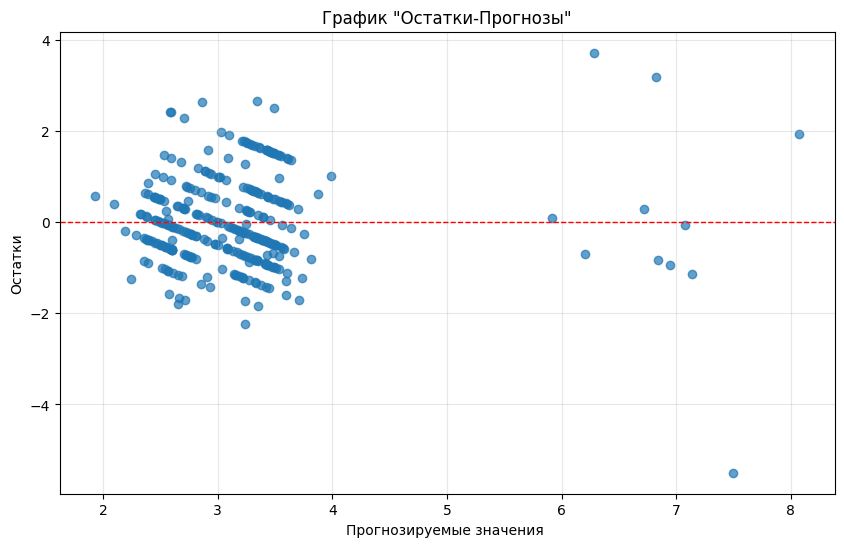

In [11]:
# График Остатки-прогнозы

fitted_values = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(10, 6))
plt.scatter(fitted_values, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Прогнозируемые значения ')
plt.ylabel('Остатки')
plt.title('График "Остатки-Прогнозы"')
plt.grid(True, alpha=0.3)
plt.show()

`Вывод:` нулевая гипотеза отвергается, значит тест на остуствие гетероскедастичности считаем не пройденым. Дополнительно смотрим на график Остатки-прогнозы и тоже видим потенциальную гетероскедастичность при высоких ценах. Поэтому будем исопльзвоать поправку через .fit(cov_type='HC3')

In [12]:
## переоцениваем моедль заново

model = sm.OLS(y, X).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     price_in_thousands   R-squared:                       0.389
Model:                            OLS   Adj. R-squared:                  0.367
Method:                 Least Squares   F-statistic:                     9.556
Date:                Thu, 07 May 2026   Prob (F-statistic):           7.78e-15
Time:                        23:48:34   Log-Likelihood:                -458.08
No. Observations:                 319   AIC:                             940.2
Df Residuals:                     307   BIC:                             985.3
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

## Тестирование на нормальность отстков

In [13]:
residuals = model.resid

from scipy.stats import jarque_bera
stat, p_value = jarque_bera(residuals)

print(f'pvalue={round(p_value, 4)}')
# p_value < 0.05 → отвергаем H0, остатки НЕ нормальны

pvalue=0.0


`Вывод:` тест на нормальность остатков не пройден, проверим другие функциональные формы

# 🚀Подбор функциональной формы

#### Тестируем полулогарифмическую модель

In [14]:
X.isna().sum()

const                         0
has_higher_sport_education    0
sport_master                  0
sport_master_kandidate        0
is_champion                   0
reviews_count                 0
photos_count                  0
is_male                       0
exp_centered2                 0
exp_centered                  0
reputation_density            0
is_outlier                    0
dtype: int64

In [15]:
y_log = np.log(y)
model_logy = sm.OLS(y_log, X).fit(cov_type='HC3')
print(model_logy.summary())

                            OLS Regression Results                            
Dep. Variable:     price_in_thousands   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     8.952
Date:                Thu, 07 May 2026   Prob (F-statistic):           7.62e-14
Time:                        23:48:34   Log-Likelihood:                -93.325
No. Observations:                 319   AIC:                             210.6
Df Residuals:                     307   BIC:                             255.8
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

### Строим линейную в логарифмах модель

In [16]:
cols_not_dummi = ['reviews_count', 'photos_count', 'exp_centered2', 'reputation_density'] # не берем exp_centered, т.к. теперь берем логаричм

X_log = X.copy().drop(columns=['exp_centered'])
for col in cols_not_dummi:
    X_log[col] = np.log1p(X_log[col])

model_log_log = sm.OLS(y_log, X_log).fit(cov_type='HC3')
print(model_log_log.summary())

                            OLS Regression Results                            
Dep. Variable:     price_in_thousands   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     7.517
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.02e-10
Time:                        23:48:34   Log-Likelihood:                -94.651
No. Observations:                 319   AIC:                             211.3
Df Residuals:                     308   BIC:                             252.7
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

#### Тест Бокса-Кокса для выбора между линйной в логарифмах и линейной моделью

In [17]:
from scipy.stats import boxcox

y_boxcox, fitted_lambda = boxcox(data_priced['price_in_thousands'])

print(f"Оптимальное лямбда: {fitted_lambda:.4f}")

Оптимальное лямбда: -0.0021


`Вывод:` т.к. лямбда близка к 0 между линейной и линейной в логарифмах моделью выбираем линейную в логарифмах

### Тест Рамсея (выявить пропущенные переменные, неверные функциональные формы или неучтённые нелинейности в предикторах)

In [18]:
y_hat = model_log_log.fittedvalues.values
X_aug = np.column_stack([model_log_log.model.exog, y_hat**2])
model_aug = sm.OLS(model_log_log.model.endog, X_aug).fit()
p_val = model_aug.pvalues[-1]

print(f"Тест Рамсея для линейной в логарифмах модели: p-value = {p_val:.6f}")

Тест Рамсея для линейной в логарифмах модели: p-value = 0.003614


Вывод: линейная в логарифмах модель не прошла тест Рамсея, но для нашей исследовательской задачи больше подходит полулогарифмическая модель, т.к. мы хотели оценить эффект влияния увеличения признака тренера на 1 влияния в процентах на цену

In [19]:
y_hat = model_logy.fittedvalues.values
X_aug = np.column_stack([model_logy.model.exog, y_hat**2])
model_aug = sm.OLS(model_logy.model.endog, X_aug).fit()
p_val = model_aug.pvalues[-1]

print(f"Тест Рамсея для полулогарифмической модели: p-value = {p_val:.6f}")

Тест Рамсея для полулогарифмической модели: p-value = 0.006247


`Вывод:` полулогарифмическая модель не прошла тест Рамсея на ~1% значимости, так что будем править спецификацию

In [20]:
X.columns

Index(['const', 'has_higher_sport_education', 'sport_master',
       'sport_master_kandidate', 'is_champion', 'reviews_count',
       'photos_count', 'is_male', 'exp_centered2', 'exp_centered',
       'reputation_density', 'is_outlier'],
      dtype='object')

### Тест Чоу

In [21]:
# Делаем тест Чоу
# Код был отредактирован синтаксически и форматно через LLM


import statsmodels.api as sm
from scipy import stats

dammi_for_test = 'is_male'

df0 = data_priced[data_priced[dammi_for_test] == 0]
df1 = data_priced[data_priced[dammi_for_test] == 1]

X_vars = ['has_higher_sport_education', 'sport_master',
       'sport_master_kandidate', 'is_champion', 'reviews_count',
       'photos_count', 'exp_centered2', 'exp_centered',
       'reputation_density', 'is_outlier'] #'is_male',  ### когда перезапустим, надо не забыть удалить нужную дамми

X0 = sm.add_constant(df0[X_vars])
X1 = sm.add_constant(df1[X_vars])

y0 = y_log.loc[df0.index]
y1 = y_log.loc[df1.index]

model0 = sm.OLS(y0, X0).fit()
model1 = sm.OLS(y1, X1).fit()

model_pooled = sm.OLS(y_log, X).fit()

RSS_pooled = sum(model_pooled.resid ** 2)
RSS_0 = sum(model0.resid ** 2)
RSS_1 = sum(model1.resid ** 2)

k = X.shape[1]
n0 = len(df0)
n1 = len(df1)

# F статистика
F = ((RSS_pooled - (RSS_0 + RSS_1)) / k) / \
    ((RSS_0 + RSS_1) / (n0 + n1 - 2 * k))

p_value = 1 - stats.f.cdf(F, k, n0 + n1 - 2 * k)

print('F-statistic:', F)
print('p-value:', round(p_value, 2))


F-statistic: 0.7963579479802922
p-value: 0.65


`Вывод:` нулевая гипотеза не отвергается, можно оценивать единую модель для мужчин и для женщин тренеров

`Важно:` Для финальной модели было решено убрать найденные выбросы, чтобы модель была гомоскедастична. Т.к. даже на графике цен виден большой разрыв до тренеров с высокой ценой, можно говорить о наличии 2 ценовых сегментов на рынке (базового и премиум сегмента(с более низкой и более высокой ценой)).

In [22]:
data_priced

,has_higher_sport_education,sport_master,sport_master_kandidate,is_champion,reviews_count,photos_count,is_male,work_experience_sq,work_experience,reputation_density,price_in_thousands,exp_centered,exp_centered2,is_outlier
0,0,0,0,0,5,10,0,16.0,4.0,1.463415,3.2,-13.208726,174.470432,0
3,0,0,0,0,0,8,1,4.0,2.0,0.000000,2.0,-15.208726,231.305334,0
4,0,1,0,0,4,0,0,9.0,3.0,2.400000,3.0,-14.208726,201.887883,0
5,1,0,0,0,1,0,0,9.0,3.0,0.666667,2.0,-14.208726,201.887883,0
6,0,0,0,0,0,8,0,49.0,7.0,0.000000,2.0,-10.208726,104.218078,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,0,0,0,0,18,0,1,25.0,5.0,2.769231,3.0,-12.208726,149.052981,0
406,0,0,0,0,0,9,1,324.0,18.0,0.000000,2.5,0.791274,0.626115,0
407,0,0,1,0,0,2,0,25.0,5.0,0.000000,3.0,-12.208726,149.052981,0
410,1,1,0,1,1,2,0,16.0,4.0,0.266667,5.0,-13.208726,174.470432,0


In [23]:
## удалим данные тренеров премиум сегмента
data_priced = data_priced[data_priced['is_outlier'] == 0].drop('is_outlier', axis=1)

### Оценим модель заново

y_log=np.log(data_priced['price_in_thousands'])
X = sm.add_constant(data_priced[['has_higher_sport_education', 'sport_master',
       'sport_master_kandidate', 'is_champion', 'reviews_count',
       'photos_count', 'exp_centered2', 'exp_centered',
       'reputation_density', 'is_male']])

model = sm.OLS(y_log, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     price_in_thousands   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.166
Method:                 Least Squares   F-statistic:                     7.114
Date:                Thu, 07 May 2026   Prob (F-statistic):           4.80e-10
Time:                        23:48:34   Log-Likelihood:                -81.213
No. Observations:                 308   AIC:                             184.4
Df Residuals:                     297   BIC:                             225.5
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

### Улучшение текушей модели

In [24]:
cur_model_res = sm.OLS(y_log, X).fit()

worst_p = cur_model_res.pvalues.drop('const').max()
worst_var = cur_model_res.pvalues.drop('const').idxmax()
worst_p

##  критерии текущей модели
print(f"Текущий AIC: {cur_model_res.aic:.2f} | BIC: {cur_model_res.bic:.2f}")
print(f"Худшая переменная: '{worst_var}' (p-value = {worst_p:.4f})")
print("-" * 30)

Текущий AIC: 184.43 | BIC: 225.46
Худшая переменная: 'exp_centered' (p-value = 0.6095)
------------------------------


In [25]:
cur_model_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     price_in_thousands   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.166
Method:                 Least Squares   F-statistic:                     7.114
Date:                Thu, 07 May 2026   Prob (F-statistic):           4.80e-10
Time:                        23:48:34   Log-Likelihood:                -81.213
No. Observations:                 308   AIC:                             184.4
Df Residuals:                     297   BIC:                             225.5
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.8851      0.053     16.768      0.000       0.781       0.989
has_higher_sport_education    -0.0456      0.040     -1.153      0.250      -0.124       0.032
sport_master                   0.2319      0.048      4.859      0.000       0.138       0.326
sport_master_kandidate         0.1316      0.070      1.883      0.061      -0.006       0.269
is_champion                    0.0998      0.047      2.132      0.034       0.008       0.192
reviews_count                 -0.0014      0.002     -0.789      0.431      -0.005       0.002
photos_count                   0.0108      0.003      3.148      0.002       0.004       0.018
exp_centered2                 -0.0003      0.000     -1.729      0.085      -0.001    4.79e-05
exp_centered                  -0.0014      0.003     -0.511      0.609      -0.007       0.004
reputation_density             0.0119      0.010      1.148      0.252      -0.008       0.032
is_male                       -0.0215      0.038     -0.567      0.571      -0.096       0.053
==============================================================================
Omnibus:                       10.977   Durbin-Watson:                   2.047
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               11.499
Skew:                          -0.399   Prob(JB):                      0.00318
Kurtosis:                       3.508   Cond. No.                         599.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Уберем переменную `exp_centered`

In [26]:
cur_model_res = sm.OLS(y_log, X.drop('exp_centered', axis=1)).fit()

worst_p = cur_model_res.pvalues.drop('const').max()
worst_var = cur_model_res.pvalues.drop('const').idxmax()
worst_p

##  критерии текущей модели
print(f"Текущий AIC: {cur_model_res.aic:.2f} | BIC: {cur_model_res.bic:.2f}")
print(f"Худшая переменная: '{worst_var}' (p-value = {worst_p:.4f})")
print("-" * 30)

Текущий AIC: 182.70 | BIC: 220.00
Худшая переменная: 'is_male' (p-value = 0.5126)
------------------------------


In [27]:
cur_model_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     price_in_thousands   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.168
Method:                 Least Squares   F-statistic:                     7.895
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.84e-10
Time:                        23:48:35   Log-Likelihood:                -81.348
No. Observations:                 308   AIC:                             182.7
Df Residuals:                     298   BIC:                             220.0
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.8946      0.049     18.128      0.000       0.797       0.992
has_higher_sport_education    -0.0506      0.038     -1.321      0.187      -0.126       0.025
sport_master                   0.2285      0.047      4.842      0.000       0.136       0.321
sport_master_kandidate         0.1316      0.070      1.886      0.060      -0.006       0.269
is_champion                    0.1024      0.046      2.203      0.028       0.011       0.194
reviews_count                 -0.0016      0.002     -0.918      0.359      -0.005       0.002
photos_count                   0.0110      0.003      3.223      0.001       0.004       0.018
exp_centered2                 -0.0003      0.000     -1.654      0.099      -0.001       6e-05
reputation_density             0.0129      0.010      1.269      0.205      -0.007       0.033
is_male                       -0.0246      0.037     -0.656      0.513      -0.098       0.049
==============================================================================
Omnibus:                       10.708   Durbin-Watson:                   2.042
Prob(Omnibus):                  0.005   Jarque-Bera (JB):               11.170
Skew:                          -0.394   Prob(JB):                      0.00375
Kurtosis:                       3.498   Cond. No.                         592.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Итог: правильно убрали переменную `exp_centered`, *AIC* и *BIC* упали

### Уберем переменную `is_male`

In [28]:
cur_model_res = sm.OLS(y_log, X.drop(['is_male', 'exp_centered'], axis=1)).fit()

worst_p = cur_model_res.pvalues.drop('const').max()
worst_var = cur_model_res.pvalues.drop('const').idxmax()
worst_p

##  критерии текущей модели
print(f"Текущий AIC: {cur_model_res.aic:.2f} | BIC: {cur_model_res.bic:.2f}")
print(f"Худшая переменная: '{worst_var}' (p-value = {worst_p:.4f})")
print("-" * 30)

Текущий AIC: 181.14 | BIC: 214.71
Худшая переменная: 'reviews_count' (p-value = 0.3353)
------------------------------


In [29]:
cur_model_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     price_in_thousands   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     8.845
Date:                Thu, 07 May 2026   Prob (F-statistic):           7.15e-11
Time:                        23:48:35   Log-Likelihood:                -81.570
No. Observations:                 308   AIC:                             181.1
Df Residuals:                     299   BIC:                             214.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.8785      0.043     20.545      0.000       0.794       0.963
has_higher_sport_education    -0.0503      0.038     -1.315      0.190      -0.126       0.025
sport_master                   0.2314      0.047      4.931      0.000       0.139       0.324
sport_master_kandidate         0.1342      0.070      1.927      0.055      -0.003       0.271
is_champion                    0.1034      0.046      2.229      0.027       0.012       0.195
reviews_count                 -0.0016      0.002     -0.965      0.335      -0.005       0.002
photos_count                   0.0111      0.003      3.254      0.001       0.004       0.018
exp_centered2                 -0.0003      0.000     -1.638      0.103      -0.001     6.3e-05
reputation_density             0.0128      0.010      1.266      0.207      -0.007       0.033
==============================================================================
Omnibus:                       10.343   Durbin-Watson:                   2.042
Prob(Omnibus):                  0.006   Jarque-Bera (JB):               10.794
Skew:                          -0.383   Prob(JB):                      0.00453
Kurtosis:                       3.504   Cond. No.                         581.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Итог: правильно убрали переменную `is_male`, *AIC* и *BIC* упали

### Уберем переменную `reviews_count`

In [30]:
cur_model_res = sm.OLS(y_log, X.drop(['is_male', 'exp_centered', 'reviews_count'], axis=1)).fit()

worst_p = cur_model_res.pvalues.drop('const').max()
worst_var = cur_model_res.pvalues.drop('const').idxmax()
worst_p

##  критерии текущей модели
print(f"Текущий AIC: {cur_model_res.aic:.2f} | BIC: {cur_model_res.bic:.2f}")
print(f"Худшая переменная: '{worst_var}' (p-value = {worst_p:.4f})")
print("-" * 30)

Текущий AIC: 180.10 | BIC: 209.94
Худшая переменная: 'reputation_density' (p-value = 0.4108)
------------------------------


In [31]:
cur_model_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     price_in_thousands   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     9.978
Date:                Thu, 07 May 2026   Prob (F-statistic):           3.29e-11
Time:                        23:48:35   Log-Likelihood:                -82.049
No. Observations:                 308   AIC:                             180.1
Df Residuals:                     300   BIC:                             209.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.8776      0.043     20.531      0.000       0.793       0.962
has_higher_sport_education    -0.0534      0.038     -1.402      0.162      -0.128       0.022
sport_master                   0.2257      0.047      4.849      0.000       0.134       0.317
sport_master_kandidate         0.1336      0.070      1.920      0.056      -0.003       0.271
is_champion                    0.1050      0.046      2.264      0.024       0.014       0.196
photos_count                   0.0110      0.003      3.241      0.001       0.004       0.018
exp_centered2                 -0.0003      0.000     -1.524      0.128      -0.001    8.39e-05
reputation_density             0.0050      0.006      0.824      0.411      -0.007       0.017
==============================================================================
Omnibus:                       11.099   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               11.754
Skew:                          -0.396   Prob(JB):                      0.00280
Kurtosis:                       3.538   Cond. No.                         580.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Итог: правильно убрали переменную `reviews_count`, *AIC* и *BIC* упали

### Уберем переменную `reputation_density`

In [32]:
cur_model_res = sm.OLS(y_log, X.drop(['is_male', 'exp_centered', 'reviews_count', 'reputation_density'], axis=1)).fit()

worst_p = cur_model_res.pvalues.drop('const').max()
worst_var = cur_model_res.pvalues.drop('const').idxmax()
worst_p

##  критерии текущей модели
print(f"Текущий AIC: {cur_model_res.aic:.2f} | BIC: {cur_model_res.bic:.2f}")
print(f"Худшая переменная: '{worst_var}' (p-value = {worst_p:.4f})")
print("-" * 30)

Текущий AIC: 178.79 | BIC: 204.90
Худшая переменная: 'has_higher_sport_education' (p-value = 0.1546)
------------------------------


In [33]:
cur_model_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     price_in_thousands   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     11.54
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.25e-11
Time:                        23:48:35   Log-Likelihood:                -82.397
No. Observations:                 308   AIC:                             178.8
Df Residuals:                     301   BIC:                             204.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.8834      0.042     20.964      0.000       0.800       0.966
has_higher_sport_education    -0.0544      0.038     -1.427      0.155      -0.129       0.021
sport_master                   0.2260      0.047      4.859      0.000       0.134       0.318
sport_master_kandidate         0.1372      0.069      1.977      0.049       0.001       0.274
is_champion                    0.1034      0.046      2.233      0.026       0.012       0.195
photos_count                   0.0119      0.003      3.676      0.000       0.006       0.018
exp_centered2                 -0.0003      0.000     -1.522      0.129      -0.001    8.43e-05
==============================================================================
Omnibus:                       10.269   Durbin-Watson:                   2.045
Prob(Omnibus):                  0.006   Jarque-Bera (JB):               10.646
Skew:                          -0.386   Prob(JB):                      0.00488
Kurtosis:                       3.485   Cond. No.                         580.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
cur_model_res.params

const                         0.883412
has_higher_sport_education   -0.054359
sport_master                  0.226033
sport_master_kandidate        0.137225
is_champion                   0.103389
photos_count                  0.011900
exp_centered2                -0.000288
dtype: float64

### Итог: правильно убрали переменную `reputation_density`, *AIC* и *BIC* упали

## Закончили удаление признаков

### Еще раз переделаем `work_experience`

In [35]:
X = sm.add_constant(data_priced[['has_higher_sport_education', 'sport_master',
       'sport_master_kandidate', 'is_champion', 'reviews_count', 'photos_count', 'is_male',
       'work_experience_sq', 'work_experience', 'reputation_density']]).drop(['is_male', 'reviews_count', 'reputation_density'], axis=1)

model = sm.OLS(y_log, X).fit()
print(model.summary())
beta_exp = model.params['work_experience']
beta_exp2 = model.params['work_experience_sq']

peak = -beta_exp / (2 * beta_exp2)

data_priced['exp_centered'] = data_priced['work_experience'] - peak
data_priced['exp_centered2'] = data_priced['exp_centered'] ** 2

                            OLS Regression Results                            
Dep. Variable:     price_in_thousands   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     9.976
Date:                Thu, 07 May 2026   Prob (F-statistic):           3.31e-11
Time:                        23:48:35   Log-Likelihood:                -82.055
No. Observations:                 308   AIC:                             180.1
Df Residuals:                     300   BIC:                             209.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

## Итоговая модель

In [36]:
X = sm.add_constant(data_priced[['has_higher_sport_education', 'sport_master',
'sport_master_kandidate', 'is_champion', 'photos_count', 'exp_centered2']]) ## итоговые X

In [37]:
model = sm.OLS(y_log, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     price_in_thousands   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     11.68
Date:                Thu, 07 May 2026   Prob (F-statistic):           9.14e-12
Time:                        23:48:35   Log-Likelihood:                -82.055
No. Observations:                 308   AIC:                             178.1
Df Residuals:                     301   BIC:                             204.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.8752      0.039     22.675      0.000       0.799       0.951
has_higher_sport_education    -0.0462      0.038     -1.211      0.227      -0.121       0.029
sport_master                   0.2318      0.046      5.020      0.000       0.141       0.323
sport_master_kandidate         0.1368      0.069      1.973      0.049       0.000       0.273
is_champion                    0.0990      0.046      2.141      0.033       0.008       0.190
photos_count                   0.0116      0.003      3.578      0.000       0.005       0.018
exp_centered2                 -0.0003      0.000     -1.730      0.085      -0.001    4.68e-05
==============================================================================
Omnibus:                       10.655   Durbin-Watson:                   2.051
Prob(Omnibus):                  0.005   Jarque-Bera (JB):               11.095
Skew:                          -0.394   Prob(JB):                      0.00390
Kurtosis:                       3.493   Cond. No.                         488.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [38]:
# Тест Бройша-Пагана
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(model.resid, model.model.exog)
print(f"LM stat: {bp_test[0]:.4f}, p-value: {bp_test[1]:.4f}")

LM stat: 1.3157, p-value: 0.9708


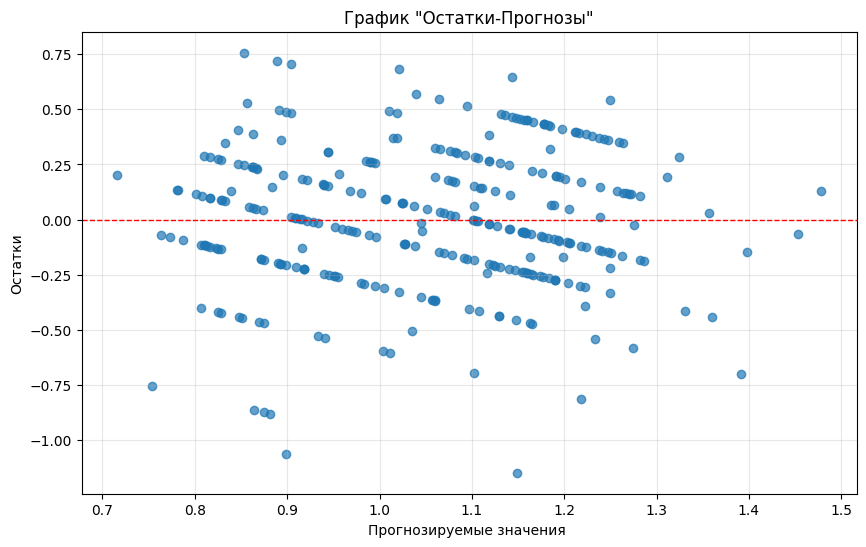

In [39]:
# График Остатки-прогнозы

fitted_values = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(10, 6))
plt.scatter(fitted_values, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Прогнозируемые значения ')
plt.ylabel('Остатки')
plt.title('График "Остатки-Прогнозы"')
plt.grid(True, alpha=0.3)
plt.show()

`Вывод:` нулевая гипотеза не отвергается, значит тест на остуствие гетероскедастичности считаем пройденым.

In [40]:
residuals = model.resid

from scipy.stats import jarque_bera
stat, p_value = jarque_bera(residuals)

print(f'pvalue={round(p_value, 4)}')
# p_value < 0.05 → отвергаем H0, остатки НЕ нормальны

pvalue=0.0039


`Вывод:` нулевая гипотеза не отвергается, значит остатки не нормальны, значит используем робастные ошибки

In [41]:
model_hc3 = sm.OLS(y_log, X).fit(cov_type='HC3')
print(model_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:     price_in_thousands   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     11.56
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.19e-11
Time:                        23:48:35   Log-Likelihood:                -82.055
No. Observations:                 308   AIC:                             178.1
Df Residuals:                     301   BIC:                             204.2
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [42]:
y_hat = model_hc3.fittedvalues.values
X_aug = np.column_stack([model_hc3.model.exog, y_hat**2])
model_aug = sm.OLS(model_hc3.model.endog, X_aug).fit()
p_val = model_aug.pvalues[-1]

print(f"Тест Рамсея для полулогарифмической модели: p-value = {p_val:.6f}")

Тест Рамсея для полулогарифмической модели: p-value = 0.237138


`Вывод:` финальная полулогарифмическая модель прошла тест Рамсея, p-value = 0.237138, спецификация верна

### Модель Хекмана

In [43]:
## делаем датасет для всех
df2 = pd.read_csv('processed_data_tennis.csv')
df2['years_on_profi_ru'] = df2['months_on_profi_ru'] / 12
df2.drop('months_on_profi_ru', axis=1, inplace=True)
df2['price_in_thousands'] = df2['price'] / 1000
df2.drop('price', axis=1, inplace=True)
df2['cur_score_percents'] = df2['cur_score'] / 100
df2.drop('cur_score', axis=1, inplace=True)
df2['work_experience_sq'] = df2['work_experience'] ** 2
df2['reputation_density'] = df2['reviews_count'] / (df2['years_on_profi_ru'] + 1)
df2['reputation_volume_interaction'] = df2['rating'] * np.log(df2['reviews_count'] + 1)
df2['champion_experience_inter'] = df2['is_champion'] * df2['years_on_profi_ru']

df2['exp_centered'] = df2['work_experience'] - peak
df2['exp_centered2'] = df2['exp_centered'] ** 2


In [44]:
df2_cleaned = df2.drop(high_stud_res.index) ## уберем выбросы еще раз
df2_cleaned

,has_secondary_sport_education,has_higher_sport_education,sport_master,sport_master_kandidate,is_champion,work_experience,master_id,rang_id,docs_verified,rating,...,has_price,years_on_profi_ru,price_in_thousands,cur_score_percents,work_experience_sq,reputation_density,reputation_volume_interaction,champion_experience_inter,exp_centered,exp_centered2
0,1,0,0,0,0,4.0,https://profi.ru/profile/AbelkhairovaSV/,86.0,1,5.0,...,1,2.416667,3.2,0.504935,16.0,1.463415,8.958797,0.000000,-10.121757,102.449974
1,1,0,0,0,0,19.0,https://profi.ru/profile/AbramovMB/,111.0,0,0.0,...,0,0.166667,NaN,0.504337,361.0,0.000000,0.000000,0.000000,4.878243,23.797250
2,0,1,1,0,1,8.0,https://profi.ru/profile/AbyasovaAN/,100.0,0,0.0,...,0,2.583333,NaN,0.503504,64.0,0.000000,0.000000,2.583333,-6.121757,37.475915
3,1,0,0,0,0,2.0,https://profi.ru/profile/AfanasyevBA4/,144.0,1,0.0,...,1,1.250000,2.0,0.503303,4.0,0.000000,0.000000,0.000000,-12.121757,146.937004
4,1,0,1,0,0,3.0,https://profi.ru/profile/AgureyevaKM2/,75.0,1,5.0,...,1,0.666667,3.0,0.505121,9.0,2.400000,8.047190,0.000000,-11.121757,123.693489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,1,0,0,1,0,5.0,https://profi.ru/profile/ZhirkovaVA10/,136.0,0,0.0,...,1,0.166667,3.0,0.500943,25.0,0.000000,0.000000,0.000000,-9.121757,83.206459
408,1,0,0,0,0,13.0,https://profi.ru/profile/ZhuchkovaVS3/,136.0,0,0.0,...,0,0.750000,NaN,0.500192,169.0,0.000000,0.000000,0.000000,-1.121757,1.258340
409,1,0,1,0,1,9.0,https://profi.ru/profile/ZhukovMA78/,103.0,1,0.0,...,0,0.083333,NaN,0.504611,81.0,0.000000,0.000000,0.083333,-5.121757,26.232400
410,0,1,1,0,1,4.0,https://profi.ru/profile/ZykovaDS2/,84.0,0,5.0,...,1,2.750000,5.0,0.504794,16.0,0.266667,3.465736,2.750000,-10.121757,102.449974


In [45]:
probit_model = smf.probit('has_price ~ work_experience + docs_verified + years_on_profi_ru + reviews_count', data=df2_cleaned).fit(method='bfgs')

df2_cleaned['lambda'] = stats.norm.pdf(probit_model.predict(linear=True)) / stats.norm.cdf(probit_model.predict(linear=True))

Optimization terminated successfully.
         Current function value: 0.475764
         Iterations: 16
         Function evaluations: 20
         Gradient evaluations: 20


c:\Users\123в\git_rep_bot\.conda\Lib\site-packages\statsmodels\discrete\discrete_model.py:530: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


In [46]:
probit_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:              has_price   No. Observations:                  401
Model:                         Probit   Df Residuals:                      396
Method:                           MLE   Df Model:                            4
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1215
Time:                        23:48:35   Log-Likelihood:                -190.78
converged:                       True   LL-Null:                       -217.18
Covariance Type:            nonrobust   LLR p-value:                 9.431e-11
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.0443      0.138     -0.320      0.749      -0.316       0.227
work_experience       0.0161      0.010      1.580      0.114      -0.004       0.036
docs_verified         0.5807      0.157      3.696      0.000       0.273       0.889
years_on_profi_ru     0.0862      0.028      3.076      0.002       0.031       0.141
reviews_count         0.0014      0.006      0.248      0.804      -0.010       0.012
=====================================================================================
"""

In [47]:
df2_cleaned_price = df2_cleaned[df2_cleaned['has_price'] == 1].copy()
X_heck = pd.concat([X, df2_cleaned_price['lambda']], axis=1) ## добавим lambda
X_heck

,const,has_higher_sport_education,sport_master,sport_master_kandidate,is_champion,photos_count,exp_centered2,lambda
0,1.0,0,0,0,0,10,102.449974,0.360748
3,1.0,0,0,0,0,8,146.937004,0.422859
4,1.0,0,1,0,0,0,123.693489,0.436271
5,1.0,1,0,0,0,0,123.693489,0.767249
6,1.0,0,0,0,0,8,50.719429,0.428830
...,...,...,...,...,...,...,...,...
405,1.0,0,0,0,0,0,83.206459,0.246720
406,1.0,0,0,0,0,9,15.040765,0.587364
407,1.0,0,0,1,0,2,83.206459,0.765928
410,1.0,1,1,0,1,2,102.449974,0.640937


In [48]:
# Уравнение цены для тех, кто указал цену
model_heckman = sm.OLS(y_log, X_heck).fit(cov_type='HC3')
print(model_heckman.summary())

                            OLS Regression Results                            
Dep. Variable:     price_in_thousands   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     9.880
Date:                Thu, 07 May 2026   Prob (F-statistic):           4.27e-11
Time:                        23:48:35   Log-Likelihood:                -81.921
No. Observations:                 308   AIC:                             179.8
Df Residuals:                     300   BIC:                             209.7
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

### Вывод: эфффект отбора не значим, значит можем использовать OLS

### Сделаем прогноз для человека
- Высшее спортивное образование
- Без спортивных званий и регалий
- Стаж 10 лет
- 5 фотографий в профиле


In [49]:
exp_sq_man_base = (10 - peak) ** 2
print(f'exp_centered2: {exp_sq_man_base}')

exp_centered2: 16.988884651972274


In [50]:
data_base = pd.DataFrame({'const': 1, 'has_higher_sport_education': 1, 'sport_master': 0, 'sport_master_kandidate': 0,
    'is_champion': 0, 'photos_count': 5, 'exp_centered2': exp_sq_man_base}, index=[0])

In [51]:
# Точечный прогноз
wage_pred =  np.exp(model_hc3.predict(data_base))
point_estimate = wage_pred.iloc[0]

# Доверительный интервал
prediction = model_hc3.get_prediction(data_base)
pred_summary = prediction.summary_frame(alpha=0.05)

ci_lower =np.exp(pred_summary['mean_ci_lower'].iloc[0])
ci_upper =np.exp(pred_summary['mean_ci_upper'].iloc[0])

print(f"Точечный прогноз: {point_estimate:.2f} тысяч руб.")
print(f"95% ДИ: [{ci_lower:.2f}, {ci_upper:.2f}] тысяч руб.")

Точечный прогноз: 2.41 тысяч руб.
95% ДИ: [2.22, 2.63] тысяч руб.


### Сделаем прогноз для человека
- Высшее спортивное образование
- Мастер спорта + чемпион
- Стаж 15 лет (около пика параболы)
- 20 фотографий в профиле


In [52]:
exp_sq_man_pro = (15 - peak) ** 2
print(f'exp_centered2: {exp_sq_man_base}')

exp_centered2: 16.988884651972274


In [53]:
data_pro = pd.DataFrame({'const': 1, 'has_higher_sport_education': 1, 'sport_master': 1, 'sport_master_kandidate': 0,
    'is_champion': 1, 'photos_count': 20, 'exp_centered2': exp_sq_man_pro}, index=[0])

In [54]:
# Точечный прогноз
wage_pred = np.exp(model_hc3.predict(data_pro))
point_estimate = wage_pred.iloc[0]

# Доверительный интервал
prediction = model_hc3.get_prediction(data_pro)
pred_summary = prediction.summary_frame(alpha=0.05)

ci_lower =np.exp(pred_summary['mean_ci_lower'].iloc[0])
ci_upper =np.exp(pred_summary['mean_ci_upper'].iloc[0])

print(f"Точечный прогноз: {point_estimate:.2f} тысяч руб.")
print(f"95% ДИ: [{ci_lower:.2f}, {ci_upper:.2f}] тысяч руб.")

Точечный прогноз: 4.02 тысяч руб.
95% ДИ: [3.55, 4.55] тысяч руб.


<Axes: xlabel='цена', ylabel='количество тренеров'>

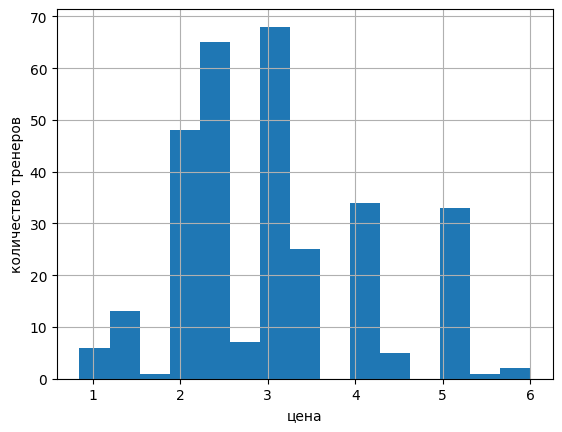

In [55]:
plt.xlabel('цена')
plt.ylabel('количество тренеров')
data_priced['price_in_thousands'].hist(bins=15)

СТАТИСТИКА: До порога: 132 | После: 36
Результат RDD (скачок в log): -1.4555
p-value: 0.0034
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8712      0.457      6.277      0.000       1.975       3.768
rv             0.6538      0.270      2.417      0.016       0.124       1.184
above         -1.4555      0.497     -2.926      0.003      -2.430      -0.481
rv_above      -0.6973      1.291     -0.540      0.589      -3.227       1.833


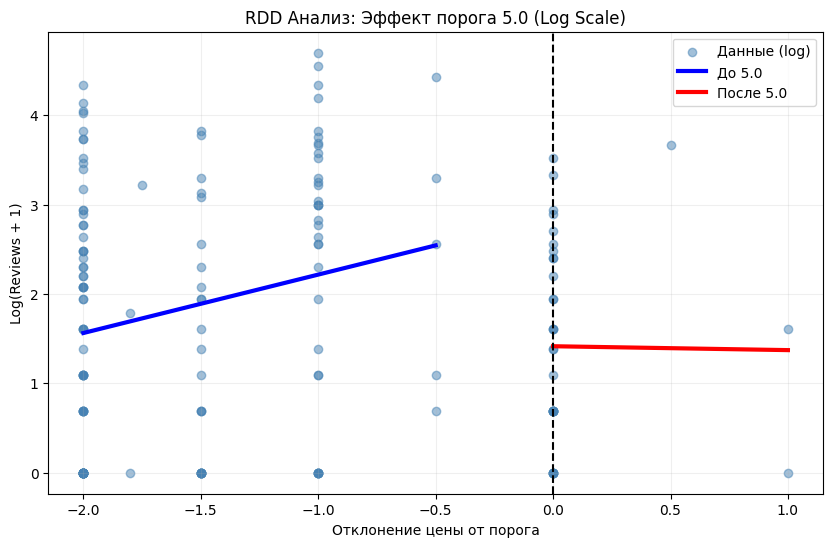


Интерпретация: При переходе через порог количество отзывов меняется на -76.67%


In [56]:
threshold = 5.0 ## порговая цена, видим из графика
data_priced['rv'] = data_priced['price_in_thousands'] - threshold
data_priced['above'] = (data_priced['rv'] >= 0).astype(int)
data_priced['rv_above'] = data_priced['rv'] * data_priced['above']

# Логарифмируем, чтобы убрать влияние выбросов
data_priced['log_reviews'] = np.log1p(data_priced['reviews_count'])

# Увеличиваем окно до 2.0, чтобы захватить больше точек слева
bw = 2.0
df_local = data_priced[data_priced['rv'].abs() <= bw].copy()

# Используем логарифм для стабилизации ошибки
model_rdd = smf.ols('log_reviews ~ rv + above + rv_above', data=df_local).fit(cov_type='HC3')

n_below = (df_local['above'] == 0).sum()
n_above = (df_local['above'] == 1).sum()

print(f"СТАТИСТИКА: До порога: {n_below} | После: {n_above}")
print(f"Результат RDD (скачок в log): {model_rdd.params['above']:.4f}")
print(f"p-value: {model_rdd.pvalues['above']:.4f}")
print(model_rdd.summary().tables[1])

plt.figure(figsize=(10, 6))

plt.scatter(df_local['rv'], df_local['log_reviews'], color='steelblue', alpha=0.5, label='Данные (log)')

# Линии тренда
for side, color, label in zip([0, 1], ['blue', 'red'], ['До 5.0', 'После 5.0']):
    subset = df_local[df_local.above == side].sort_values('rv')
    if not subset.empty:
        preds = model_rdd.predict(subset)
        plt.plot(subset['rv'], preds, color=color, lw=3, label=label)

plt.axvline(0, color='black', linestyle='--')
plt.title(f'RDD Анализ: Эффект порога {threshold} (Log Scale)')
plt.xlabel('Отклонение цены от порога')
plt.ylabel('Log(Reviews + 1)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Перевод логарифмического коэффициента в проценты для интерпретации
jump_pct = (np.exp(model_rdd.params['above']) - 1) * 100
print(f"\nИнтерпретация: При переходе через порог количество отзывов меняется на {jump_pct:.2f}%")

### вывод: рекомендуется удерживать цену товара в пределах до 4999 руб. Превышение порога в 5000 руб. приводит к резкому падению активности пользователей более чем на 76%

### Графики для презы

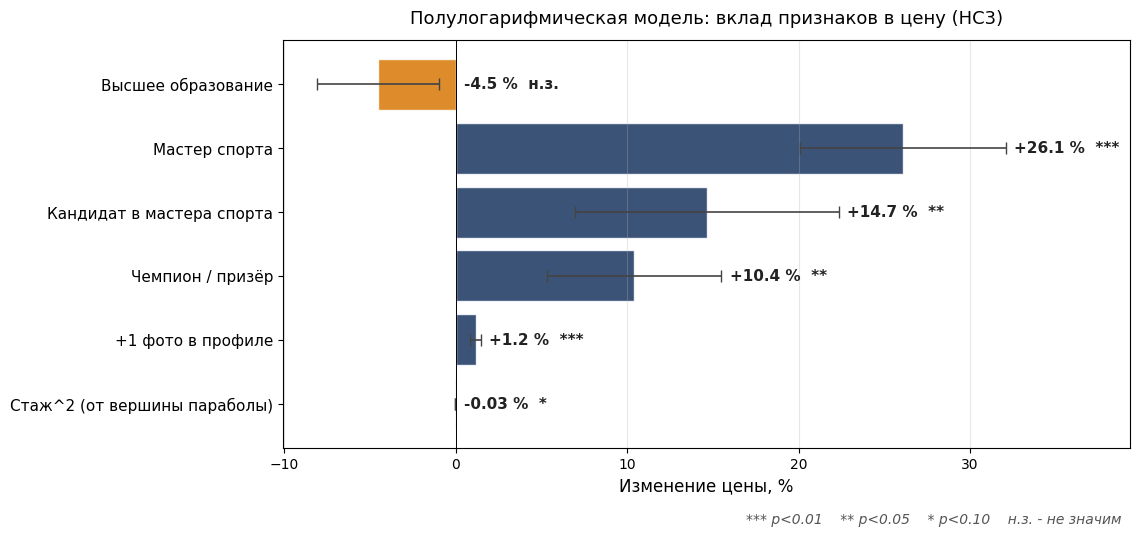

In [57]:
NAVY = '#1a3560'
ORANGE = '#d97706'

names_map = {
    'has_higher_sport_education': 'Высшее образование',
    'sport_master':               'Мастер спорта',
    'sport_master_kandidate':     'Кандидат в мастера спорта',
    'is_champion':                'Чемпион / призёр',
    'photos_count':               '+1 фото в профиле',
    'exp_centered2':              'Стаж^2 (от вершины параболы)',
}

labels, effects, ses_pct, sigs = [], [], [], []
for name in model_hc3.params.index:
    if name == 'const':
        continue
    coef = model_hc3.params[name]
    se   = model_hc3.bse[name]
    p    = model_hc3.pvalues[name]

    # Полуэластичность: процентное изменение цены
    pct_eff = (np.exp(coef) - 1) * 100
    pct_se  = (np.exp(coef + se) - np.exp(coef - se)) / 2 * 100

    if   p < 0.01: sig = '***'
    elif p < 0.05: sig = '**'
    elif p < 0.10: sig = '*'
    else:          sig = 'н.з.'

    labels.append(names_map.get(name, name))
    effects.append(pct_eff)
    ses_pct.append(pct_se)
    sigs.append(sig)

fig, ax = plt.subplots(figsize=(11.5, 5.5))
y_pos = np.arange(len(labels))
colors = [NAVY if e > 0 else ORANGE for e in effects]

ax.barh(y_pos, effects, xerr=ses_pct, color=colors, alpha=0.85,
        edgecolor='white', capsize=4,
        error_kw={'ecolor': '#444', 'lw': 1.2})

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.invert_yaxis()  # самый сильный эффект сверху
ax.axvline(0, color='black', linewidth=0.7)
ax.set_xlabel('Изменение цены, %', fontsize=12)
ax.set_title('Полулогарифмическая модель: вклад признаков в цену (HC3)',
             fontsize=13, pad=12)
ax.grid(axis='x', alpha=0.3)

# Расширяем правую границу, чтобы подписи помещались
xmax = max(e + se for e, se in zip(effects, ses_pct))
xmin = min(e - se for e, se in zip(effects, ses_pct))
span = xmax - xmin
ax.set_xlim(xmin - span * 0.05, xmax + span * 0.18)

# Подписи всегда справа от правого конца error-bar, не пересекают yticklabels
xpad = span * 0.012
for i, (e, se, sig) in enumerate(zip(effects, ses_pct, sigs)):
    fmt = f'{e:+.2f}' if abs(e) < 0.1 else f'{e:+.1f}'
    label = f'{fmt} %  {sig}'
    ax.text(max(e + se, 0) + xpad, i, label,
            va='center', ha='left',
            fontsize=11, color='#222', fontweight='bold')

# Легенда уровней значимости под графиком
ax.text(0.99, -0.16,
        '*** p<0.01    ** p<0.05    * p<0.10    н.з. - не значим',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=10, style='italic', color='#555')

plt.tight_layout()
plt.show()


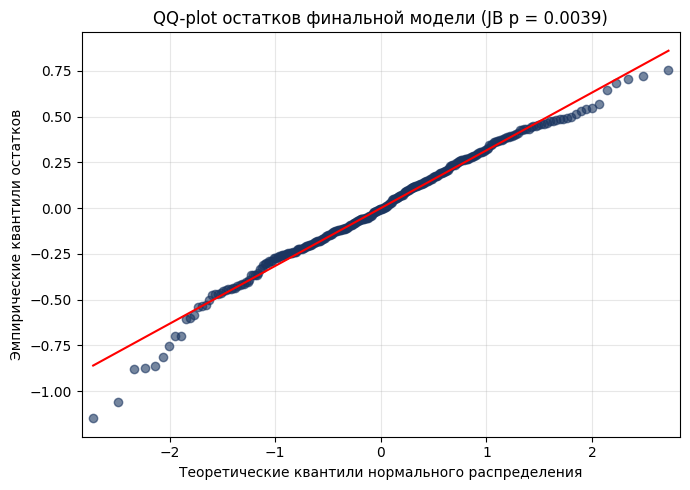

In [58]:
fig, ax = plt.subplots(figsize=(7, 5))
sm.qqplot(model.resid, line='s', ax=ax,
          markerfacecolor='#1a3560', markeredgecolor='#1a3560', alpha=0.6)
ax.set_title(f'QQ-plot остатков финальной модели (JB p = {round(p_value, 4)})')
ax.set_xlabel('Теоретические квантили нормального распределения')
ax.set_ylabel('Эмпирические квантили остатков')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


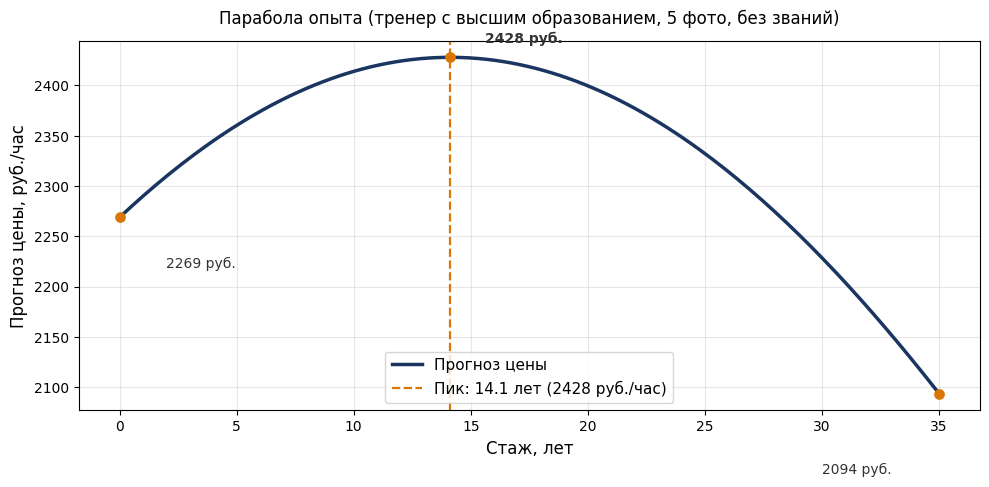

In [59]:
# Парабола опыта: прогноз цены при разном стаже
# (для тренера с высшим образованием, 5 фото, без званий)
NAVY   = '#1a3560'
ORANGE = '#d97706'
# Коэффициенты финальной HC3-модели и пик параболы (peak вычислен в cell 65)
icpt = model_hc3.params['const']
b_hh = model_hc3.params['has_higher_sport_education']
b_ph = model_hc3.params['photos_count']
b_e2 = model_hc3.params['exp_centered2']
# Фиксируем профиль: высшее образование = 1, фото = 5, званий нет
xs    = np.linspace(0, 35, 200)
xc    = xs - peak
log_p = icpt + b_e2 * xc**2 + b_hh * 1 + b_ph * 5
ps    = np.exp(log_p) * 1000  # из тыс. руб. в рубли
# Прогноз в характерных точках для аннотаций
def price_at(x):
    return float(np.exp(icpt + b_e2 * (x - peak)**2 + b_hh + b_ph * 5) * 1000)
p_peak = price_at(peak)
p_0    = price_at(0)
p_35   = price_at(35)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(xs, ps, color=NAVY, lw=2.5, label='Прогноз цены')
ax.axvline(peak, color=ORANGE, linestyle='--', lw=1.6,
           label=f'Пик: {peak:.1f} лет ({p_peak:.0f} руб./час)')
# Точечные подписи в трёх характерных точках
ax.scatter([0, peak, 35], [p_0, p_peak, p_35], color=ORANGE, zorder=5, s=45)
ax.annotate(f'{p_0:.0f} руб.', xy=(0, p_0), xytext=(2, p_0 - 50),
            fontsize=10, color='#333')
ax.annotate(f'{p_peak:.0f} руб.', xy=(peak, p_peak), xytext=(peak + 1.5, p_peak + 15),
            fontsize=10, color='#333', fontweight='bold')
ax.annotate(f'{p_35:.0f} руб.', xy=(35, p_35), xytext=(30, p_35 - 80),
            fontsize=10, color='#333')
ax.set_xlabel('Стаж, лет', fontsize=12)
ax.set_ylabel('Прогноз цены, руб./час', fontsize=12)
ax.set_title('Парабола опыта (тренер с высшим образованием, 5 фото, без званий)',
             fontsize=12, pad=12)
ax.legend(fontsize=11, loc='lower center')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
